In [59]:
from pathlib import Path
import os
import re
import sys
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
%matplotlib inline

import config
sys.path.insert(0, '..')
import sigmoid_fitting as sp

import random
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
def _fit_single_curve(y_row, x_time, start_idx=0):
    try:
        y_num = np.asanyarray(y_row, dtype=np.float64)
        x_num = np.asanyarray(x_time, dtype=np.float64)
        y_fit = y_num[start_idx:]
        x_fit = x_num[start_idx:]
        
        params, _ = sp.fit_5p(x_fit, y_fit, normalize=True)
        fitted_full = sp.sigmoid_5p(x_num, *params)
        fitted_segment = sp.sigmoid_5p(x_fit, *params)
        
        old_x_norm = np.linspace(0, 1, len(fitted_segment))
        new_x_norm = np.linspace(0, 1, len(x_num))
        fitted_stretched = np.interp(new_x_norm, old_x_norm, fitted_segment)
        rmse = np.sqrt(np.nanmean(np.square(fitted_segment - y_fit)))
        
        return fitted_full, fitted_stretched, params, rmse
        
    except Exception:
        nan_array = np.full_like(x_time, np.nan, dtype=np.float64)
        return nan_array, nan_array, np.full(5, np.nan), np.nan

def sigmoid_fitting_5p(curves, ori_timestamps, starting_idxs=None):
    if starting_idxs is None:
        starting_idxs = np.zeros(len(curves), dtype=int)
        
    results = Parallel(n_jobs=-1, backend="loky", batch_size='auto')(
        delayed(_fit_single_curve)(y, ori_timestamps, t) 
        for y, t in zip(curves, starting_idxs)
    )
    
    curves_out_full, curves_out_stretched, params_out, rmse_out = zip(*results)
    return np.array(curves_out_full), np.array(curves_out_stretched), np.array(params_out), np.array(rmse_out)

def get_numeric_sort_key(col_name):
    nums = re.findall(r'\d+\.?\d*', col_name)
    return float(nums[0]) if nums else 0.0

In [55]:
exp_root = config.LAB_EXP_FOLDER

file_mapping = {
    'ACA_qdPCR': 'dPCR_Dataset_Pure.csv',
    'AMCA_qdPCR': 'dPCR_Amplification_Curves.csv',
    'AMCA_qdLAMP': '5Plex_dLAMP_oldData.csv',
}

file_target = {
    'ACA_qdPCR': 'LoadedPanels',
    'AMCA_qdPCR': 'Target',
    'AMCA_qdLAMP': 'Target',
}

In [57]:
preprocesed_curves = {}
rmse_values = {}

for folder, file in file_mapping.items():
    # 1. Path Management
    dataset_path = os.path.join(exp_root, folder, file)
    exp_path = os.path.join(exp_root, folder)
    save_path = os.path.join(exp_path, config.PREPROCESSED_CURVES_PATH)
    
    # Ensure directory exists just in case
    os.makedirs(exp_path, exist_ok=True)
    
    # 2. Data Loading & Extraction
    df = pd.read_csv(dataset_path)
    
    cycle_cols = []
    for col in df.columns:
        if col.startswith('Cycle') or re.match(r'^\d+(\.\d+)?$', col):
            cycle_cols.append(col)
            
    sorted_cycle_cols = sorted(cycle_cols, key=get_numeric_sort_key)
    
    timestamps = np.array([get_numeric_sort_key(col) for col in sorted_cycle_cols])
    curve = df[sorted_cycle_cols].to_numpy()
    
    target_col = file_target[folder]
    y_well = df[target_col].to_numpy()
    
    # 3. Dynamic Baseline Shifting
    baseline_value = 0.0
    if np.min(curve) < 0:
        baseline_value = -np.min(curve) + 1e-9
        curve = curve + baseline_value

    # 4. Math Fitting Pipeline (Corrected unpacking to 4 variables)
    fitted_full, fitted_stretched, params, rmse = sigmoid_fitting_5p(curve, timestamps)

    # 5. Metadata Processing & Dict Compiling (Aligned with structured_fits format)
    preprocesed_curve = {
        'dataset_name': folder,
        'curves': {
            'ori_curves': curve,
        },
        'sigmoid_curves': {
            'original': {
                'fitted_full': fitted_full,
                'fitted_stretched': fitted_stretched,
                'params': params,
                'rmse': rmse
            }
        },
        'timestamps': timestamps,
        'well_labels': y_well,
        'baseline_value': baseline_value,
        'metadata': {}  # Explicitly empty as requested
    }
    
    rmse_values[folder] = rmse
    preprocesed_curves[folder] = preprocesed_curve
    
    # 6. Disk Serialization & Output Metrics
    joblib.dump(preprocesed_curve, save_path, compress=3)
    
    print("=" * 50)
    print(f"Processed Dataset: {folder}")
    print(f"  -> X (Curves) shape:       {curve.shape}")
    print(f"  -> well_labels (Targets):       {np.unique(y_well)}")
    print(f"  -> well_labels (Targets) shape: {y_well.shape}")
    print(f"  -> Timestamps shape:       {timestamps.shape}")
    print(f"  -> Timestamps range:       {timestamps[0]} to {timestamps[-1]}")
    print(f"  -> Mean RMSE Fit Error:    {np.nanmean(rmse):.4f}")
    print(f"  -> Saved numerical results and metadata to {save_path}\n")

Processed Dataset: ACA_qdPCR
  -> X (Curves) shape:       (16188, 45)
  -> well_labels (Targets):       ['KPC' 'NDM' 'VIM']
  -> well_labels (Targets) shape: (16188,)
  -> Timestamps shape:       (45,)
  -> Timestamps range:       0.0 to 44.0
  -> Mean RMSE Fit Error:    0.0102
  -> Saved numerical results and metadata to /vol/bitbucket/gk225/lab_dataset/ACA_qdPCR/preprocessed_curves.joblib

Processed Dataset: AMCA_qdPCR
  -> X (Curves) shape:       (58598, 45)
  -> well_labels (Targets):       ['mcr-1' 'mcr-2' 'mcr-3' 'mcr-4' 'mcr-5' 'mcr-6' 'mcr-7' 'mcr-8' 'mcr-9']
  -> well_labels (Targets) shape: (58598,)
  -> Timestamps shape:       (45,)
  -> Timestamps range:       1.0 to 45.0
  -> Mean RMSE Fit Error:    0.0089
  -> Saved numerical results and metadata to /vol/bitbucket/gk225/lab_dataset/AMCA_qdPCR/preprocessed_curves.joblib

Processed Dataset: AMCA_qdLAMP
  -> X (Curves) shape:       (54186, 35)
  -> well_labels (Targets):       ['ad' 'c19' 'ia' 'ib' 'kp']
  -> well_labels (Ta

In [61]:
sample_indices

[13835, 6311, 12418]

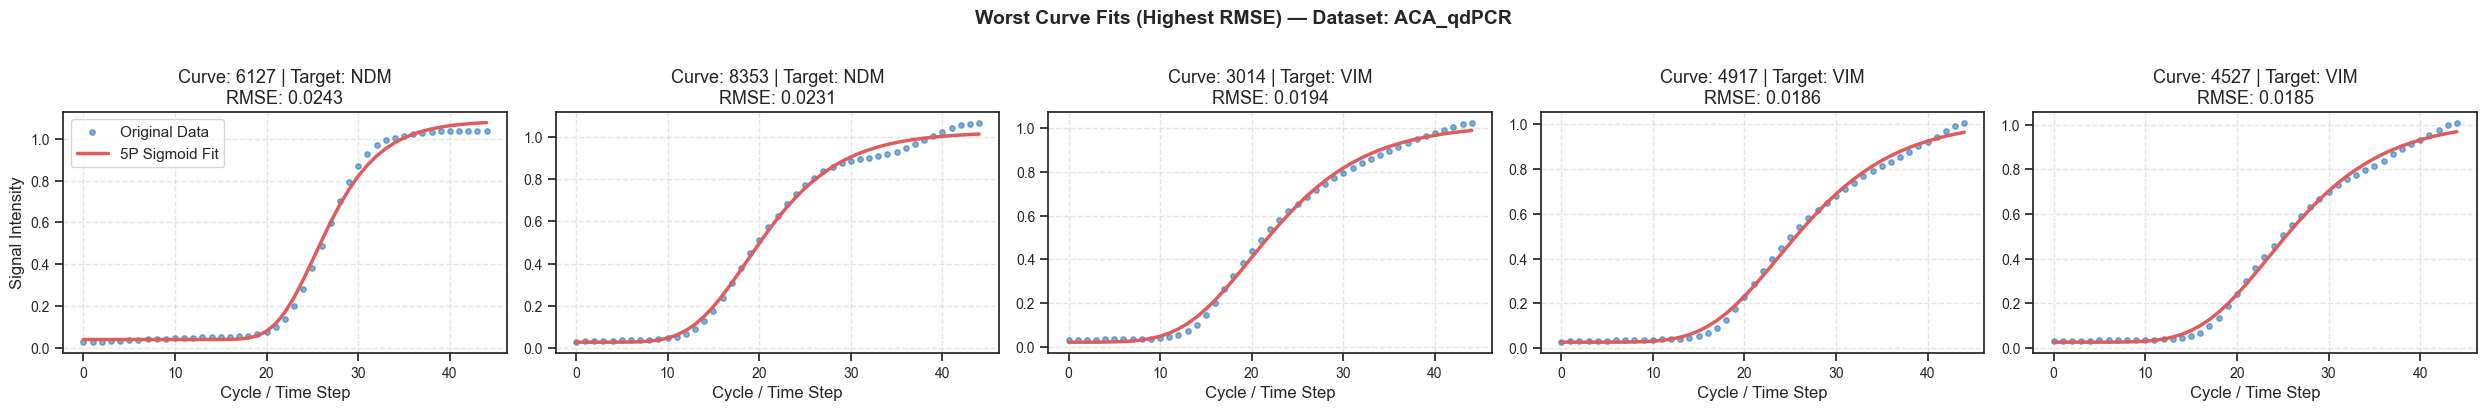

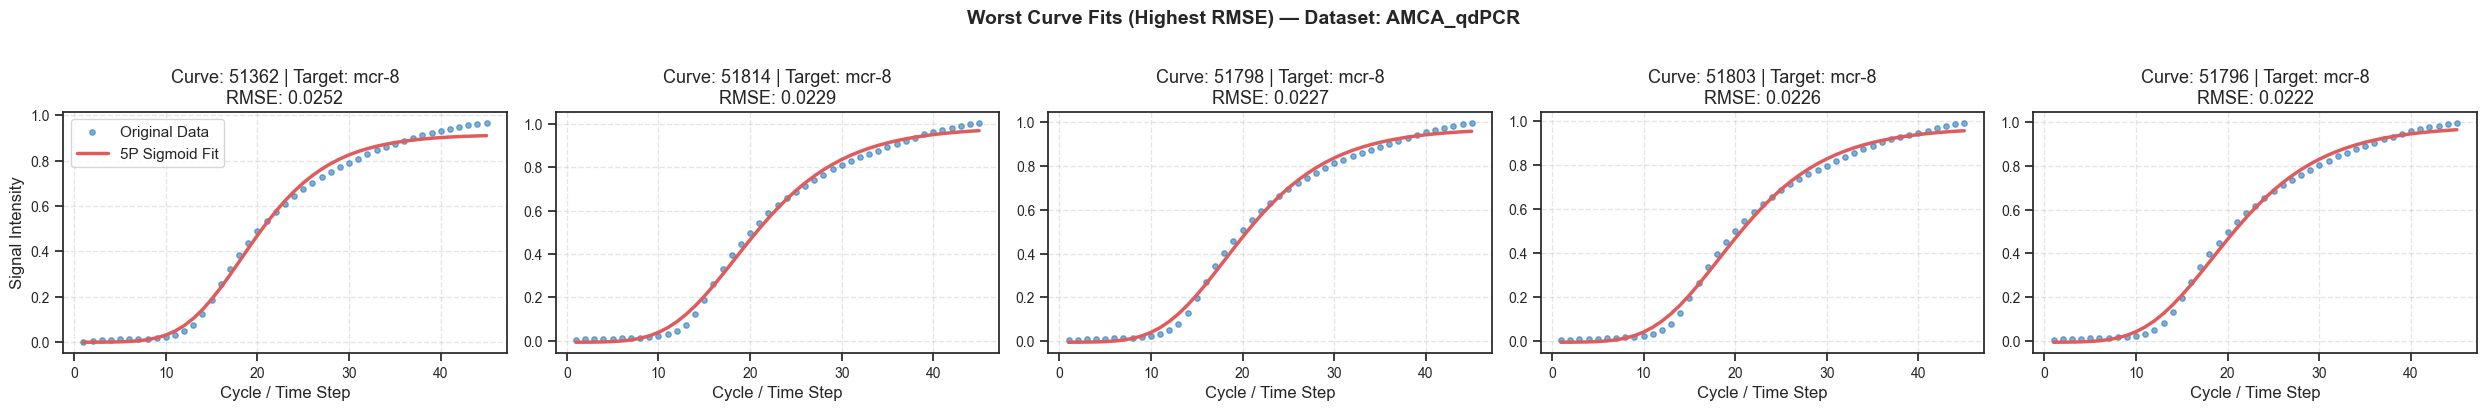

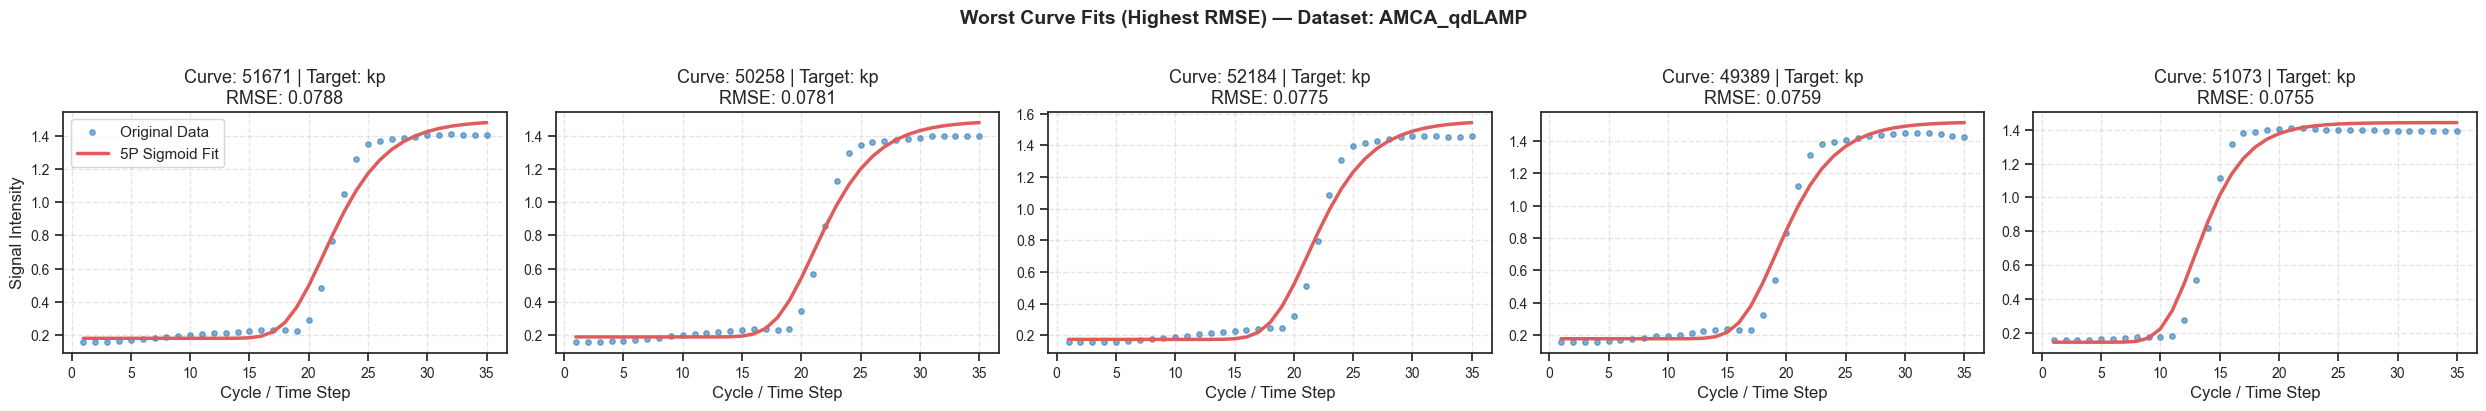

In [68]:
sns.set_theme(style="ticks")
sns.set_theme(style="ticks")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

# Number of sample curves you want to display per dataset folder
NUM_SAMPLES_TO_PLOT = 5

for folder in file_mapping.keys():
    data_dict = preprocesed_curves[folder]
    
    ori_curves = data_dict['curves']['ori_curves']          
    fitted_curves = data_dict['sigmoid_curves']['original']['fitted_full'] 
    rmse_array = data_dict['sigmoid_curves']['original']['rmse']
    timestamps = data_dict['timestamps']                    
    y_well = data_dict['well_labels']                       
    
    num_total_curves = ori_curves.shape[0]
    
    # ---------------------------------------------------------
    # NEW LOGIC: Sort by highest RMSE
    # np.argsort sorts ascending. [::-1] reverses it to descending.
    # Note: If there are NaNs (failed fits), they will appear first.
    # ---------------------------------------------------------
    sorted_indices = np.argsort(rmse_array)[::-1]
    sample_indices = sorted_indices[:min(NUM_SAMPLES_TO_PLOT, num_total_curves)]
    
    # Initialize the figure canvas (1 row, NUM_SAMPLES columns)
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(5 * len(sample_indices), 4), sharex=True)
    
    # Handle edge case where only 1 sample is plotted to keep axes iterable
    if len(sample_indices) == 1:
        axes = [axes]
        
    fig.suptitle(f"Worst Curve Fits (Highest RMSE) — Dataset: {folder}", weight='bold', y=1.02)
    
    for ax_idx, curve_idx in enumerate(sample_indices):
        ax = axes[ax_idx]
        
        # Plot original raw data points
        ax.scatter(timestamps, ori_curves[curve_idx], 
                   color='#2b7bba', alpha=0.6, s=15, label='Original Data')
        
        # Plot smooth fitted mathematical curve line
        ax.plot(timestamps, fitted_curves[curve_idx], 
                color='#e05c5c', linewidth=2.5, label='5P Sigmoid Fit')
        
        # Individual plot annotations (Updated to show RMSE)
        ax.set_title(f"Curve: {curve_idx} | Target: {y_well[curve_idx]}\nRMSE: {rmse_array[curve_idx]:.4f}")
        ax.set_xlabel("Cycle / Time Step")
        
        if ax_idx == 0:
            ax.set_ylabel("Signal Intensity")
            ax.legend(loc='upper left', frameon=True)
            
        ax.grid(True, linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

In [99]:
import numpy as np
from scipy.interpolate import interp1d, CubicSpline

# Mock Data
x_original = np.array([0, 1.2, 3.5, 4.8, 7.0])
y_original = np.array([10, 15, 12, 18, 20])

# Target Timestamp Grid: [0, t, 2t, ..., T]
t_step = 0.1
T_max = x_original[-1]
x_target = np.arange(0, T_max + t_step, t_step)

# Method 1A: Linear Interpolation (NumPy)
y_linear = np.interp(x_target, x_original, y_original)

# Method 1B: Cubic Spline (SciPy)
cs = CubicSpline(x_original, y_original)
y_cubic = cs(x_target)

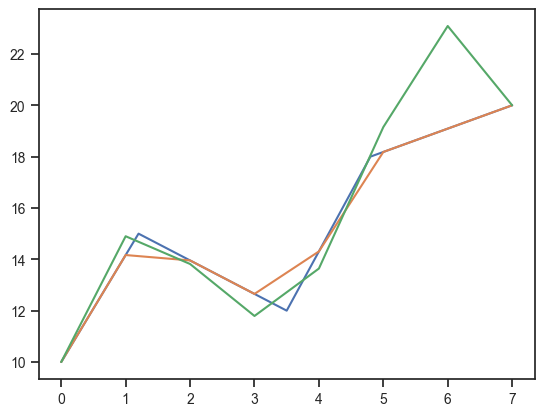

In [74]:
plt.plot(x_original, y_original, label='Original Data')
plt.plot(x_target, y_linear, label='Original Data')
plt.plot(x_target, y_cubic, label='Original Data')

In [104]:
import numpy as np
from scipy.interpolate import interp1d, CubicSpline
from scipy.stats import binned_statistic
from scipy.signal import savgol_filter


# Mock High-Frequency Noisy Data
x_original = np.sort(np.random.uniform(0, 10, 100))
y_original = np.sin(x_original) + np.random.normal(0, 0.5, 100)

# Target Grid
t_step = 0.5
x_target = np.arange(0, 15 + t_step, t_step)

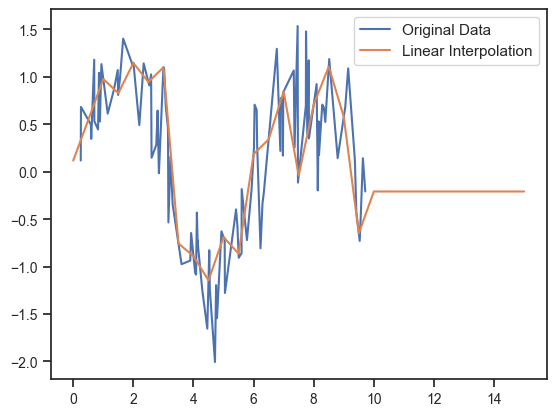

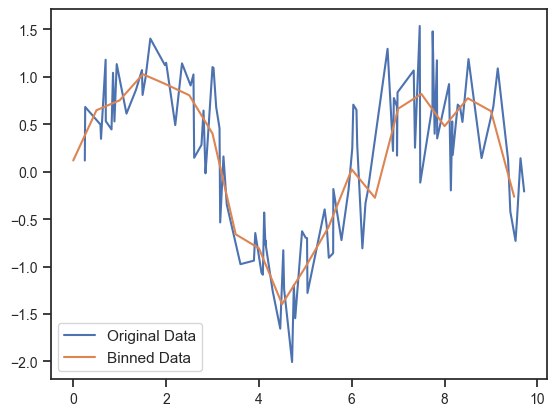

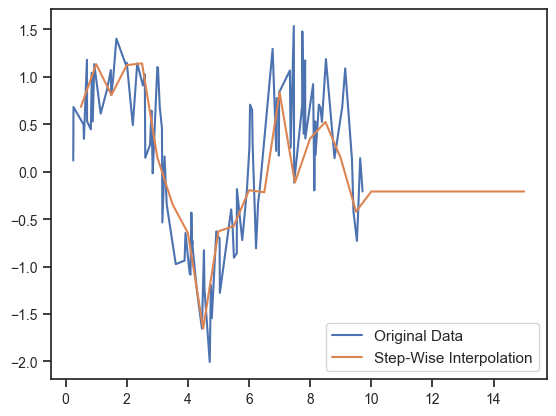

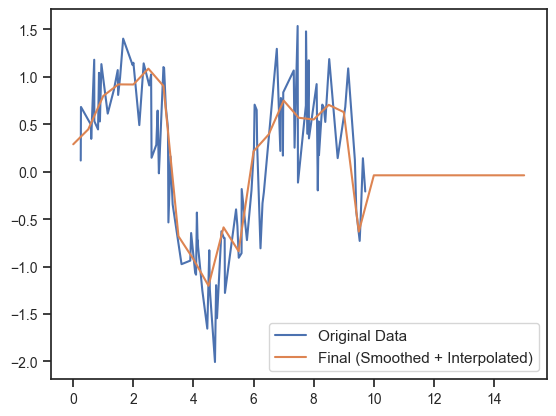

In [105]:

# ===============================================================
# Method 1A: Linear Interpolation (NumPy)
# ===============================================================
y_linear = np.interp(x_target, x_original, y_original)

plt.plot(x_original, y_original, label='Original Data')
plt.plot(x_target, y_linear, label='Linear Interpolation')
plt.legend()
plt.show() 
plt.close(fig)
# ===============================================================
# Method 1B: Cubic Spline (SciPy)
# ===============================================================
cs = CubicSpline(x_original, y_original)
y_cubic = cs(x_target)

# plt.plot(x_target, y_cubic, label='Cubic Spline')

# ===============================================================
# Binning/Aggregation Method
# ===============================================================
bin_edges = np.append(x_target - (t_step/2), x_target[-1] + (t_step/2))

# Calculate the mean of all points falling into each bin
y_binned, _, _ = binned_statistic(x_original, y_original, statistic='mean', bins=bin_edges)

plt.plot(x_original, y_original, label='Original Data')

plt.plot(x_target, y_binned, label='Binned Data')
plt.legend()
plt.show() 
plt.close(fig)
# ===============================================================
# Step-Wise / Forward-Fill Interpolation
# ===============================================================
f_step = interp1d(x_original, y_original, kind='previous', fill_value="extrapolate")
y_stepwise = f_step(x_target)

plt.plot(x_original, y_original, label='Original Data')
plt.plot(x_target, y_stepwise, label='Step-Wise Interpolation')
plt.legend()
plt.show() 
plt.close(fig)
# ===============================================================
# 4. Smoothing + Interpolation (Best for Anti-Aliasing)
# ===============================================================
# window_length must be odd, polyorder is the polynomial degree
y_smoothed = savgol_filter(y_original, window_length=5, polyorder=2)

# 2. Interpolate the smoothed data
y_final = np.interp(x_target, x_original, y_smoothed)

plt.plot(x_original, y_original, label='Original Data')
plt.plot(x_target, y_final, label='Final (Smoothed + Interpolated)')
plt.legend()
plt.show() 
plt.close(fig)